<a href="https://colab.research.google.com/github/SachinScaler/Aug25HypothesisTesting/blob/main/ANOVA%7CLecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
!wget --no-check-certificate https://drive.google.com/uc?id=1n9268qSj_5Q7KS_ntpv-wFPQC1UyJh6f -O aerofit.csv


--2025-08-27 15:42:48--  https://drive.google.com/uc?id=1n9268qSj_5Q7KS_ntpv-wFPQC1UyJh6f
Resolving drive.google.com (drive.google.com)... 74.125.134.113, 74.125.134.101, 74.125.134.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.134.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1n9268qSj_5Q7KS_ntpv-wFPQC1UyJh6f [following]
--2025-08-27 15:42:48--  https://drive.usercontent.google.com/download?id=1n9268qSj_5Q7KS_ntpv-wFPQC1UyJh6f
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.215.132, 2607:f8b0:400c:c0c::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.215.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7461 (7.3K) [application/octet-stream]
Saving to: ‘aerofit.csv’

aerofit.csv         100%[===================>]   7.29K  --.-KB/s    in 0s      

2025-08-27 15:42:50 (66.4 MB/s) - ‘

In [19]:
df_aerofit = pd.read_csv('/content/aerofit.csv')

df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [5]:
df_aerofit["Gender"].value_counts()

,count
Gender,
Male,104
Female,76


In [20]:
df_aerofit["Product"].value_counts()

,count
Product,
KP281,80
KP481,60
KP781,40


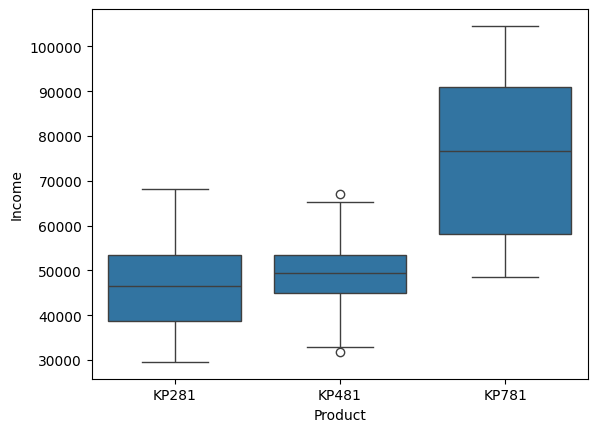

In [21]:
sns.boxplot(x='Product', y='Income', data=df_aerofit)
plt.show()

#### Let's Create a Random Group

In [22]:
np.random.seed(42)
df_aerofit["random_group"] = np.random.choice(["g1", "g2", "g3"],size=len(df_aerofit))

df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,random_group
0,KP281,18,Male,14,Single,3,4,29562,112,g3
1,KP281,19,Male,15,Single,2,3,31836,75,g1
2,KP281,19,Female,14,Partnered,4,3,30699,66,g3
3,KP281,19,Male,12,Single,3,3,32973,85,g3
4,KP281,20,Male,13,Partnered,4,2,35247,47,g1


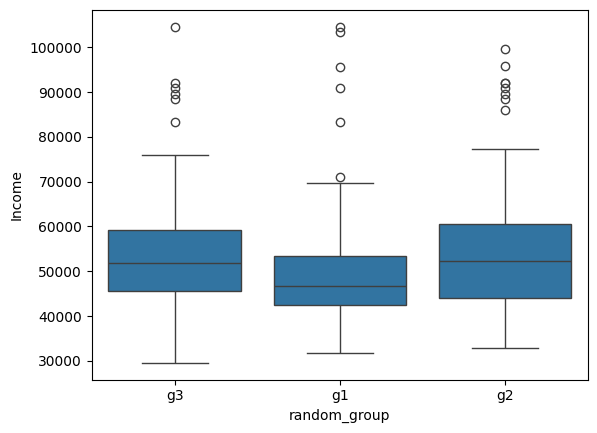

In [23]:
sns.boxplot(x='random_group', y='Income', data=df_aerofit)
plt.show()

In [24]:
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import f_oneway # Numeric Vs categorical for many categories
from scipy.stats import ttest_ind # Numeric Vs categorical



In [27]:
income_g1 = df_aerofit[df_aerofit['random_group'] == 'g1']['Income']
len(income_g1)

58

In [28]:
income_g2 = df_aerofit[df_aerofit["random_group"]=="g2"]["Income"]
income_g3 = df_aerofit[df_aerofit["random_group"]=="g3"]["Income"]

In [29]:
income_g1.mean(), income_g2.mean(), income_g3.mean()


(np.float64(51840.44827586207),
 np.float64(55812.69642857143),
 np.float64(53594.954545454544))

In [30]:
# H0: All groups have the same mean
# Ha: One or more groups have different mean
f_stats, p_value = f_oneway(income_g1, income_g2, income_g3)
print("F_stat", f_stats)
print("p_value", p_value)

F_stat 0.8263259710788367
p_value 0.4393354180119148


In [31]:
significance_level = 0.05
if p_value > significance_level:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")

Fail to reject the null hypothesis


In [32]:
df_aerofit.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,random_group
0,KP281,18,Male,14,Single,3,4,29562,112,g3
1,KP281,19,Male,15,Single,2,3,31836,75,g1
2,KP281,19,Female,14,Partnered,4,3,30699,66,g3
3,KP281,19,Male,12,Single,3,3,32973,85,g3
4,KP281,20,Male,13,Partnered,4,2,35247,47,g1


In [33]:
income_kp281 = df_aerofit[df_aerofit["Product"]=="KP281"]["Income"]
income_kp481 = df_aerofit[df_aerofit["Product"]=="KP481"]["Income"]
income_kp781 = df_aerofit[df_aerofit["Product"]=="KP781"]["Income"]


f_stats, p_value = f_oneway(income_kp281, income_kp481, income_kp781)
print("F_stat", f_stats)
print("p_value", p_value)

significance_level = 0.05
if p_value > significance_level:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")

F_stat 89.25903546601671
p_value 1.5644991316342492e-27
Reject the null hypothesis


In [34]:
from scipy.stats import ttest_ind

In [35]:
t_stat, p_value = ttest_ind(income_kp281, income_kp781)
print("t_stat", t_stat)
print("p_value", p_value)
significance_level = 0.05
if p_value > significance_level:
    print("Fail to reject the null hypothesis")
else:
    print("Reject the null hypothesis")


t_stat -11.551787854717519
p_value 4.116508528877672e-21
Reject the null hypothesis


### Try out rest of the pairs

In [36]:
from scipy.stats import kruskal

# If assumptions of ANOVA fail, use kruskal
stat, p_value = kruskal(income_g1, income_g2, income_g3)

print("test statistic:",stat)
print("p_value:",p_value)

test statistic: 2.720864198623469
p_value: 0.2565498979655774


In [37]:
from scipy.stats import kruskal

# If assumptions of ANOVA fail, use kruskal
stat, p_value = kruskal(income_kp281, income_kp481, income_kp781)

print("test statistic:",stat)
print("p_value:",p_value)

test statistic: 61.43670384567185
p_value: 4.562357014275808e-14


### Normality Tests

#### Heights Data

In [38]:
!wget --no-check-certificate https://drive.google.com/uc?id=1BbOJnKXUEPWrhjjLlZS_2-HoGvtZeubb -O weight-height.csv


--2025-08-27 16:59:29--  https://drive.google.com/uc?id=1BbOJnKXUEPWrhjjLlZS_2-HoGvtZeubb
Resolving drive.google.com (drive.google.com)... 74.125.134.113, 74.125.134.100, 74.125.134.138, ...
Connecting to drive.google.com (drive.google.com)|74.125.134.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1BbOJnKXUEPWrhjjLlZS_2-HoGvtZeubb [following]
--2025-08-27 16:59:29--  https://drive.usercontent.google.com/download?id=1BbOJnKXUEPWrhjjLlZS_2-HoGvtZeubb
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.215.132, 2607:f8b0:400c:c0c::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.215.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 428120 (418K) [application/octet-stream]
Saving to: ‘weight-height.csv’

weight-height.csv   100%[===================>] 418.09K  --.-KB/s    in 0.004s  

2025-08-27 16:59:31 (110 MB

In [39]:
path = '/content/weight-height.csv'
df_hw = pd.read_csv(path)

df_hw.head()


,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


<Axes: ylabel='Frequency'>

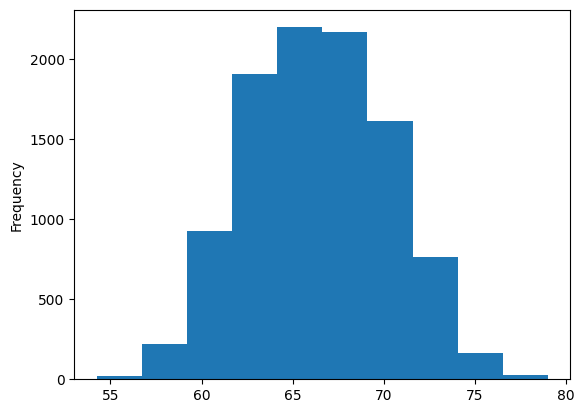

In [42]:
df_hw["Height"].plot(kind='hist')


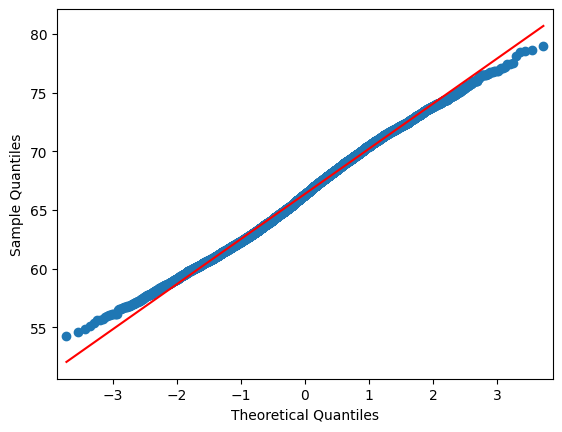

In [45]:
qqplot(df_hw["Height"], line="s")
plt.show()

### waiting time data

In [46]:
!wget --no-check-certificate https://drive.google.com/uc?id=1v48RRtiivufSX4ewrMaxsADK73GnN2kI -O waiting_time.csv


--2025-08-27 17:02:13--  https://drive.google.com/uc?id=1v48RRtiivufSX4ewrMaxsADK73GnN2kI
Resolving drive.google.com (drive.google.com)... 74.125.134.139, 74.125.134.101, 74.125.134.138, ...
Connecting to drive.google.com (drive.google.com)|74.125.134.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1v48RRtiivufSX4ewrMaxsADK73GnN2kI [following]
--2025-08-27 17:02:13--  https://drive.usercontent.google.com/download?id=1v48RRtiivufSX4ewrMaxsADK73GnN2kI
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.215.132, 2607:f8b0:400c:c0c::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.215.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1656272 (1.6M) [application/octet-stream]
Saving to: ‘waiting_time.csv’

waiting_time.csv    100%[===================>]   1.58M  --.-KB/s    in 0.01s   

2025-08-27 17:02:15 (123 MB

In [47]:
path = '/content/waiting_time.csv'
df_wt = pd.read_csv(path)

df_wt.head()

,time
0,184.003075
1,36.721521
2,29.970417
3,75.640285
4,61.489439


<Axes: ylabel='Frequency'>

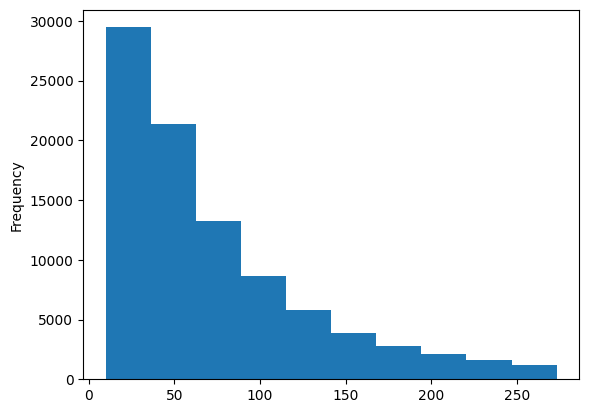

In [49]:
df_wt['time'].plot(kind = 'hist')

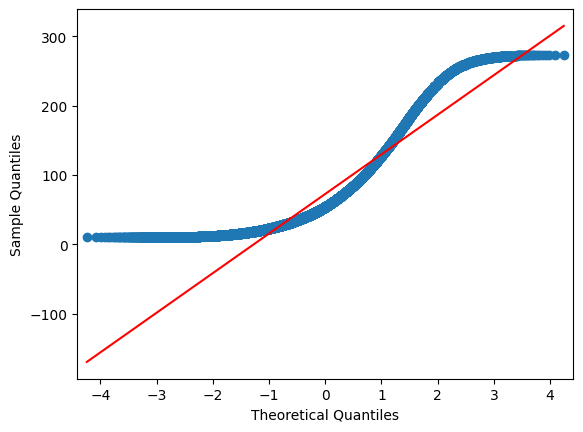

In [50]:
qqplot(df_wt['time'], line="s")
plt.show()

### Shapiro Wilk Test



In [55]:
from scipy.stats import shapiro


height_sub = df_hw["Height"].sample(1000)



In [58]:
test_stat, p_value = shapiro(df_hw["Height"])
print(p_value)

8.162481039405506e-16


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [59]:
alpha = 0.05
if p_value > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

Sample does not look Gaussian (reject H0)


Let's plot histogram or box of Height and Wieght

<Axes: xlabel='Height', ylabel='Count'>

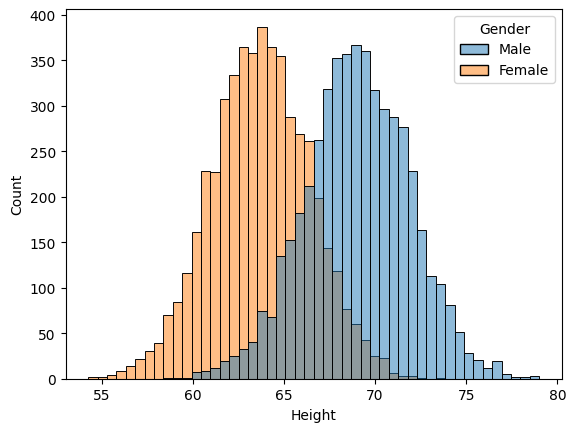

In [60]:
sns.histplot(data=df_hw, x="Height", hue="Gender")


In [62]:
height_men = df_hw[df_hw["Gender"]=="Male"]["Height"]
height_women = df_hw[df_hw["Gender"]=="Female"]["Height"]


In [63]:
print("Variance of men height:",height_men.var())
print("Variance of women height:",height_women.var())


Variance of men height: 8.19884325252049
Variance of women height: 7.269947493670132


In [64]:
from scipy.stats import levene

levene_stat, p_value = levene(height_men, height_women)
if p_value < 0.05:
    print("Variances are not equal")

Variances are not equal


In [65]:
p_value

np.float64(0.0004586349895436178)

In [66]:
wt_before = [85, 74, 63.5, 69.4, 71.6, 65,90,78]

wt_after = [82, 71, 64, 65.2, 67.8, 64.7,95,77]

from scipy.stats import ttest_rel


# Performing Paired Right-Tailed T-test
t_stat, pvalue = ttest_rel(wt_after, wt_before, alternative="less" )
print('Test Statistic:', t_stat)
print('P value:', pvalue)

Test Statistic: -1.1421853793555032
P value: 0.14546808501326386


In [67]:
t_stat, pvalue = ttest_rel(wt_before, wt_after, alternative="greater" )
print('Test Statistic:', t_stat)
print('P value:', pvalue)

Test Statistic: 1.1421853793555032
P value: 0.14546808501326386
